In [70]:
import torch
from torch import nn
from matplotlib import pyplot as plt
device = "cpu"

x ∈ [-2 , 2]

y = 1 if x² > 1

y = 0 otherwise


Tasks

Use BCEWithLogitsLoss.

Train the model.

Plot predictions.

Compute classification accuracy.


In [71]:
x=torch.arange(-2,2,0.01).unsqueeze(dim=1)
y=(x**2 >1).float()
splits = int(0.8 * len(x))
x_train,x_test = x[:splits],x[splits:]
y_train,y_test = y[:splits], y[splits:]

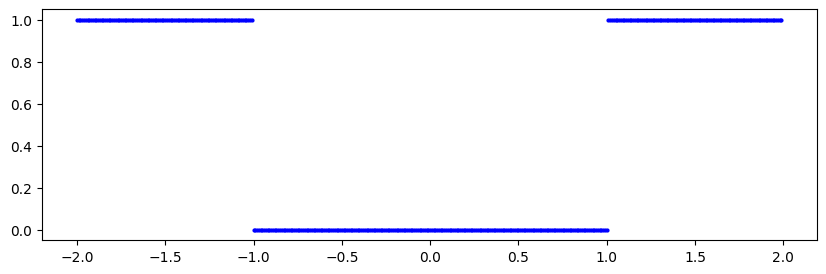

In [72]:
plt.figure(figsize=(10,3))
plt.scatter(x,y,s=4,c="b")

In [73]:
class classificationModel1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(1,8),
        nn.Linear(8,1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [74]:
model =classificationModel1()

In [75]:
model.state_dict()
paramss= model.parameters()
params = next(paramss)
param = next(paramss)
param

Parameter containing:
tensor([ 0.1664, -0.3247,  0.6179,  0.1559,  0.8080,  0.1093, -0.3154,  0.2687],
       requires_grad=True)

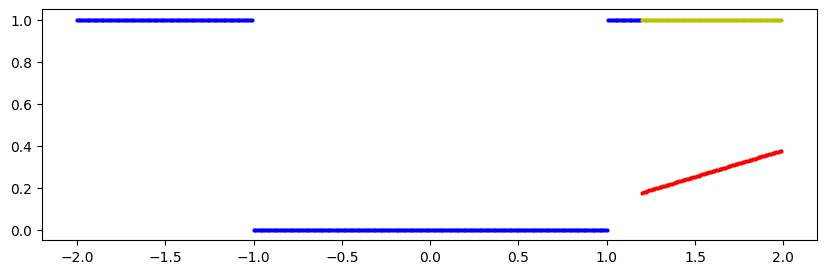

In [76]:
model.eval()
with torch.inference_mode():
  pred_untrained = model(x_test)

plt.figure(figsize=(10,3))
plt.scatter(x_train,y_train,s=4,c="b")
plt.scatter(x_test,y_test,s=4,c="y")
plt.scatter(x_test,pred_untrained,s=4,c="r")

In [77]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [78]:
epoch = 1000

for i in range(epoch):
  model.train()
  logit = model(x_train)
  loss= loss_fn(logit, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

In [79]:
def Accuracy(pred,labels):
  total = torch.eq(labels, pred).sum().item()
  accuracy = (total/len(labels)) *100
  return accuracy

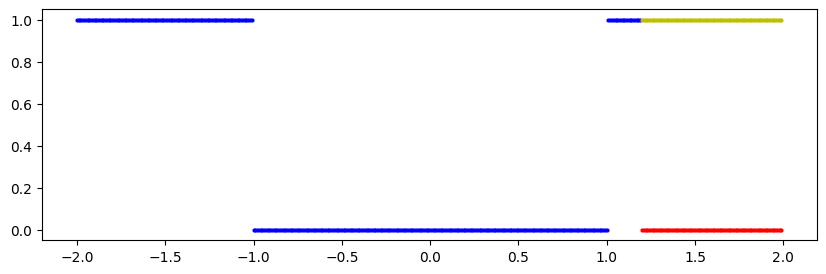

In [80]:
model.eval()
with torch.inference_mode():
  pred_trained = model(x_test)

main_pred = torch.round(torch.sigmoid(pred_trained))
# main_pred.squeeze(),y_test.squeeze()
# print(main_pred.squeeze() == y_test.squeeze())

plt.figure(figsize=(10,3))
plt.scatter(x_train,y_train,s=4,c="b")
plt.scatter(x_test,y_test,s=4,c="y")
plt.scatter(x_test,main_pred,s=4,c="r")

In [81]:
Accuracy(main_pred,y_test)

0.0

In [82]:
indexes = torch.randperm(len(x))
x=x[indexes]
y=y[indexes]
splits = int(0.8 * len(x))
x_train,x_test = x[:splits],x[splits:]
y_train,y_test = y[:splits], y[splits:]


In [83]:
epoch = 1000

for i in range(epoch):
  model.train()
  logit = model(x_train)
  loss= loss_fn(logit, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

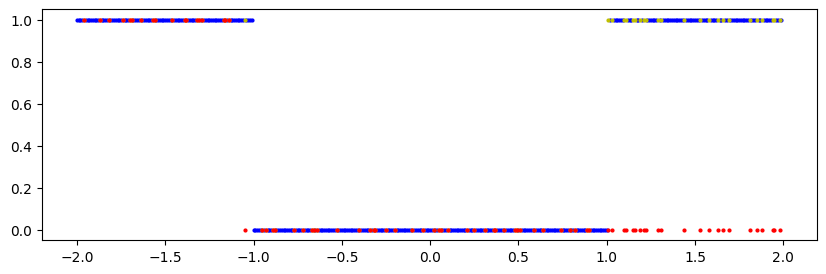

In [84]:
model.eval()
with torch.inference_mode():
  pred_trained2 = model(x_test)
main_pred2 = torch.round(torch.sigmoid(pred_trained2))

plt.figure(figsize=(10,3))
plt.scatter(x_train,y_train,s=4,c="b")
plt.scatter(x_test,y_test,s=4,c="y")
plt.scatter(x_test,main_pred2,s=4,c="r")

In [85]:
Accuracy(main_pred2,y_test)

70.0

In [86]:
class classificationModel2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1=nn.Sequential(
        nn.Linear(1,8),
        nn.ReLU(),
        nn.Linear(8,1),
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [87]:
torch.manual_seed(42)
model2 = classificationModel2()

In [88]:
optimizer = torch.optim.SGD(model2.parameters(),lr=0.01)
epochs = 1000
for i in range(epochs):
  model2.train()
  logits = model2(x_train)
  loss= loss_fn(logits,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

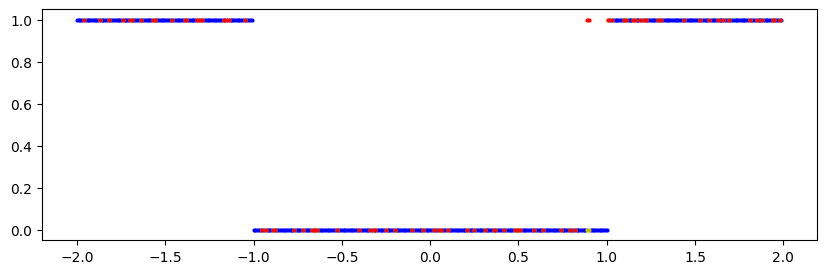

In [89]:
model2.eval()
with torch.inference_mode():
  pred_trained3 = model2(x_test)
main_pred3 = torch.round(torch.sigmoid(pred_trained3))



plt.figure(figsize=(10,3))
plt.scatter(x_train,y_train,s=4,c="b")
plt.scatter(x_test,y_test,s=4,c="y")
plt.scatter(x_test,main_pred3,s=4,c="r")

In [90]:
Accuracy(main_pred3,y_test)

97.5

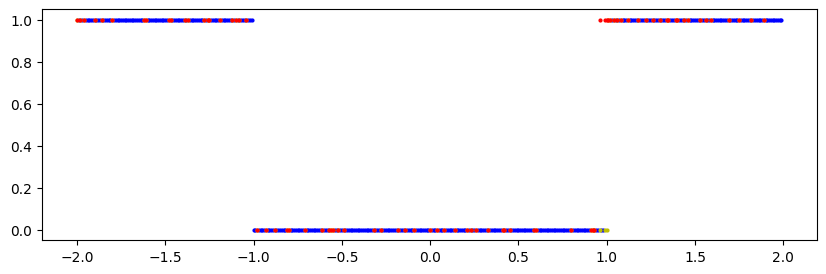

In [93]:
x=torch.arange(-2,2,0.01).unsqueeze(dim=1)
y=(x**2 >1).float()
indexes = torch.randperm(len(x))
x=x[indexes]
y=y[indexes]
splits = int(0.8 * len(x))
x_train,x_test = x[:splits],x[splits:]
y_train,y_test = y[:splits], y[splits:]

class classificationModel3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(1,16),
        nn.ReLU(),
        nn.Linear(16,1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

torch.manual_seed(42)
model =classificationModel3()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

epoch = 1000
for i in range(epoch):
  model.train()
  logit = model(x_train)
  loss= loss_fn(logit, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

model.eval()
with torch.inference_mode():
  pred_trained = model(x_test)

main_preder = torch.round(torch.sigmoid(pred_trained))
# main_preder.squeeze(),y_test.squeeze()
# print(main_preder.squeeze() == y_test.squeeze())


plt.figure(figsize=(10,3))
plt.scatter(x_train,y_train,s=4,c="b")
plt.scatter(x_test,y_test,s=4,c="y")
plt.scatter(x_test,main_preder,s=4,c="r")

In [94]:
acu = Accuracy(main_preder,y_test)
accs = (main_preder.squeeze() == y_test.squeeze()).float().mean() * 100
print(f"Accuracy: {accs:.2f}% | {acu}")

Accuracy: 96.25% | 96.25
